# What is a sketch
- A sketch is a probabilistic data structure.
- Goal: summarize large data streams with bounded memory.
- You trade exactness for approximation + guarantees.

# The quantile estimation problem
- Quantiles (median, p99, etc.) describe the distribution.
- Exact computation requires keeping all data in memory.
- Each new value means resorting/recomputing → expensive.
- Unlike mean/variance, quantiles can’t be updated incrementally with just sums.

# DDSketch: a quantile estimation sketch
- Solution: maintain an approximate distribution using buckets.
- DDSketch guarantees relative error (better for heavy-tailed data).

This is very important. Say you are tracking your system latanceies with a
quantile sketch with a rank accuracy of 0.005, and ask for the 99th
percentile. We are guaranteed to get a value between the 98.5th and
99.5th percentile. In this case this is anywhere from 2 to 20 seconds
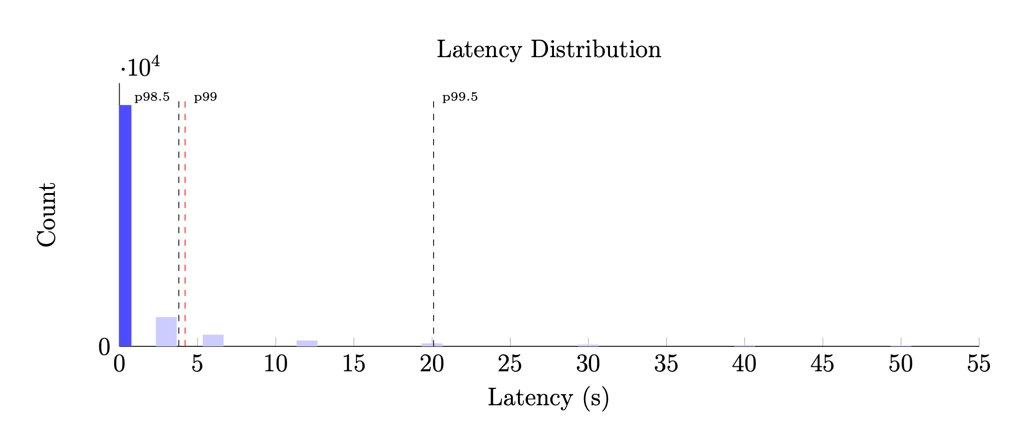


# How DDSketch works
- Index mapping: map each value x → bucket index i = ceil(logγ(x)).
- Each bucket covers a range of values (geometric spacing).
- Store: keeps counters for each bucket.
- Collapsing: if memory cap exceeded, collapse extreme buckets (low or high).
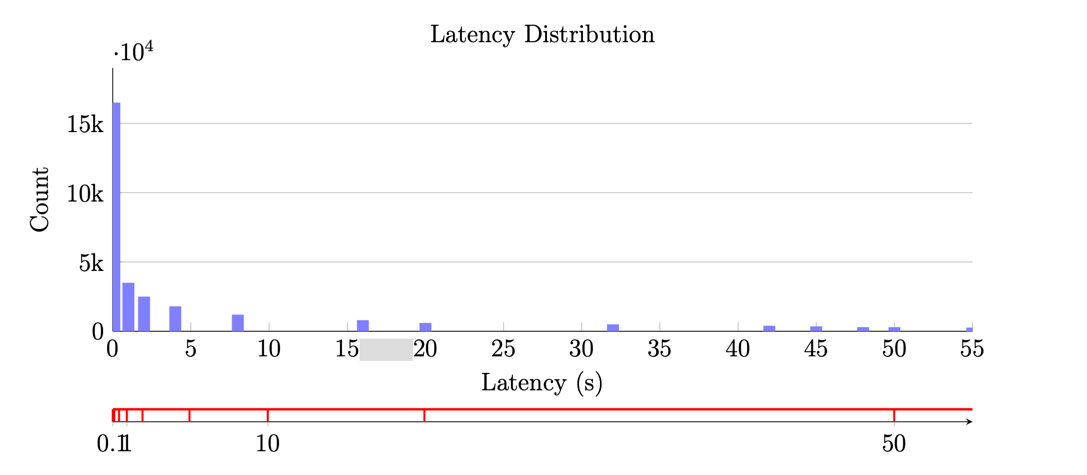

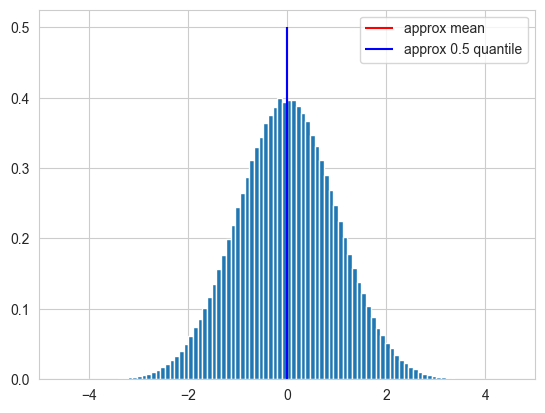

In [69]:
gaussian = np.random.normal(0, 1, size=1_000_000)


plt.hist(gaussian, bins=100, density=True)
plt.vlines(np.mean(gaussian), ymin=0, ymax=0.5, color='r', label="approx mean")
plt.vlines(np.quantile(gaussian, 0.5), ymin=0, ymax=0.5, color='b', label="approx 0.5 quantile")
plt.xlim((-5, 5))
plt.legend()

In [70]:
sk = ddsketch(0.03)
for v in gaussian:
  sk.update(v)

In [71]:
print(sk)
print(sk.get_serialized_size_bytes())

### ddsketch summary:
   Index mapping         
      gamma             : 1.06186
      index offset      : 0
      relative accuracy : 0.03
   Min indexable value   : 2.36271e-308
   Max indexable value   : 1.74533e+308
   Positive store        
      Type              : sparse store
      Bins number       : 205
   Negative store        
      Type              : sparse store
      Bins number       : 202
   Zero count             0
### End ddsketch summary

4932


1. Compute the base parameter:
$$
\gamma = \frac{1 + \alpha}{1 - \alpha}
$$
2. Map a value \(x > 0\) to its bucket index:

$$
i = \left\lceil \log_{\gamma}(x) \right\rceil
$$

3. Recover the approximate value from a bucket index:

$$
\tilde{x}(i) = \frac{2 \, \gamma^i}{\gamma + 1}
$$

# Sketch series
- A series of sketches
- Often, you compute one sketch per time window (e.g., every 1s).
- Each sketch summarizes the distribution of values during that period.

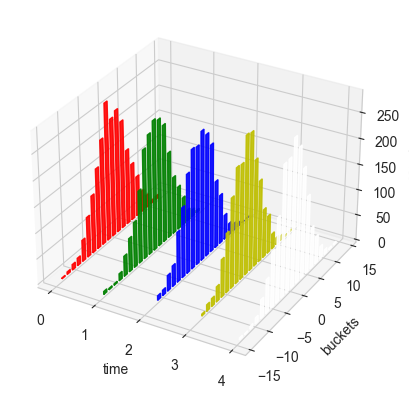

In [73]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
nbins = 50
for c, z in zip(['r', 'g', 'b', 'y', 'w'], [i for i in range(5)]):

    ys = np.random.normal(0, 4, size=2000)

    hist, bins = np.histogram(ys, bins=20)
    xs = (bins[:-1] + bins[1:])/2

    ax.bar(xs, hist, zs=z, zdir='x', color=c, ec=c, alpha=0.9)

ax.set_xlabel('time')
ax.set_ylabel('buckets')
ax.set_zlabel('counts')

plt.show()

# Aggregation
- DDSketch is mergeable: two sketches with the same config can be combined by adding bucket counts.
- This lets you:
- Aggregate across time (rolling windows),
- Aggregate across machines in distributed systems.